In [1]:
"""
SMART ENERGY SYSTEM - LSTM MODEL TRAINING (REAL DATASET)
Author:
Roshan2156
Vatsal
Zeel
"""

# ===============================
# IMPORT LIBRARIES
# ===============================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SMART ENERGY SYSTEM - LSTM MODEL TRAINING")
print("="*80)

SMART ENERGY SYSTEM - LSTM MODEL TRAINING


In [6]:
# ===============================
# STEP 1: LOAD DATA (UPLOAD IN COLAB)
# ===============================

from google.colab import files
uploaded = files.upload()

X = np.load("X.npy")
y = np.load("y.npy")
scaler = joblib.load("scaler.pkl")

print("\n✅ Data Loaded Successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Saving X.npy to X (2).npy
Saving y.npy to y.npy
Saving scaler.pkl to scaler.pkl

✅ Data Loaded Successfully!
X shape: (19976, 24, 7)
y shape: (19976,)


In [7]:
# ===============================
# STEP 2: TRAIN TEST SPLIT
# ===============================

train_size = int(0.8 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("\n📊 Data Split:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)



📊 Data Split:
Train: (15980, 24, 7)
Test: (3996, 24, 7)


In [8]:
# ===============================
# STEP 3: BUILD LSTM MODEL
# ===============================

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("\n🧠 Model Summary:")
model.summary()



🧠 Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,569 (209.25 KB)

 Trainable params: 53,569 (209.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ===============================
# STEP 4: TRAIN MODEL
# ===============================

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

print("\n✅ Model training completed")

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.0536 - mae: 0.1581 - val_loss: 0.0533 - val_mae: 0.1705
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - loss: 0.0528 - mae: 0.1580 - val_loss: 0.0526 - val_mae: 0.1563
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0526 - mae: 0.1578 - val_loss: 0.0528 - val_mae: 0.1646
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0525 - mae: 0.1579 - val_loss: 0.0525 - val_mae: 0.1566
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0525 - mae: 0.1580 - val_loss: 0.0526 - val_mae: 0.1551
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0525 - mae: 0.1580 - val_loss: 0.0528 - val_mae: 0.1659
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0525 - mae: 0.1584 - val_loss: 0.0527 - val_mae: 0.1517
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0525 - mae: 0.1580 - val_loss: 0.0526 - val_mae: 0.1542
Epoch 9/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 

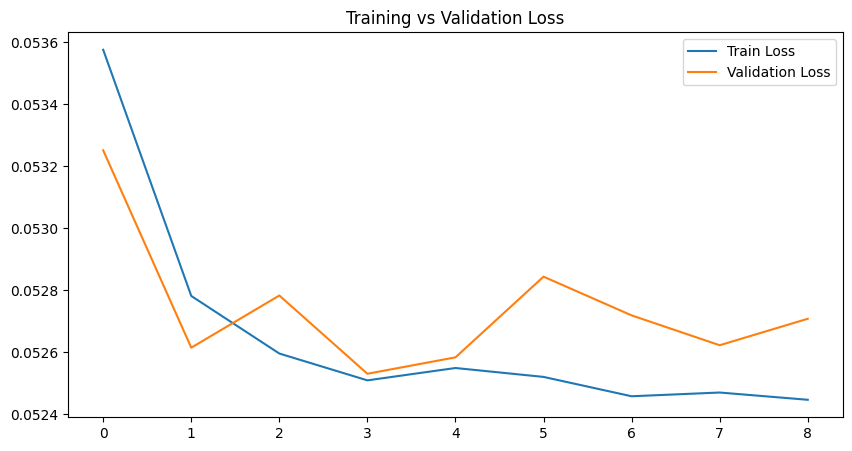

In [10]:
# ===============================
# STEP 5: VISUALIZATION
# ===============================

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


In [11]:
# ===============================
# STEP 6: MODEL EVALUATION
# ===============================

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Model Performance:")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step

📊 Model Performance:
MAE: 0.14917761553319284
RMSE: 0.22498657656899682
R2 Score: -0.002125301699321014


In [12]:
# ===============================
# STEP 8: SAVE MODEL
# ===============================

os.makedirs("models", exist_ok=True)

model.save("models/lstm_model.h5")

print("\n✅ Model saved successfully")



✅ Model saved successfully


In [13]:
# ===============================
# STEP 9: DOWNLOAD MODEL
# ===============================

from google.colab import files
files.download("models/lstm_model.h5")

print("\n🎉 LSTM MODEL TRAINING COMPLETE!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 LSTM MODEL TRAINING COMPLETE!
